<a href="https://colab.research.google.com/github/Marwan77770/Moreeee_Image_Processing-/blob/main/retinal_blood_vessel_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

path = kagglehub.dataset_download("abdallahwagih/retina-blood-vessel")

print("Path to dataset files:", path)

100%|██████████| 32.9M/32.9M [00:00<00:00, 159MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/abdallahwagih/retina-blood-vessel/versions/1


In [ ]:
import os

dataset_path = "/root/.cache/kagglehub/datasets/abdallahwagih/retina-blood-vessel/versions/1"

for root, dirs, files in os.walk(dataset_path):
    print("Folder:", root)
    print("Files sample:", files[:5])
    print("-"*50)

Folder: /root/.cache/kagglehub/datasets/abdallahwagih/retina-blood-vessel/versions/1
Files sample: []
--------------------------------------------------
Folder: /root/.cache/kagglehub/datasets/abdallahwagih/retina-blood-vessel/versions/1/Data
Files sample: []
--------------------------------------------------
Folder: /root/.cache/kagglehub/datasets/abdallahwagih/retina-blood-vessel/versions/1/Data/train
Files sample: []
--------------------------------------------------
Folder: /root/.cache/kagglehub/datasets/abdallahwagih/retina-blood-vessel/versions/1/Data/train/image
Files sample: ['49.png', '55.png', '70.png', '45.png', '23.png']
--------------------------------------------------
Folder: /root/.cache/kagglehub/datasets/abdallahwagih/retina-blood-vessel/versions/1/Data/train/mask
Files sample: ['49.png', '55.png', '70.png', '45.png', '23.png']
--------------------------------------------------
Folder: /root/.cache/kagglehub/datasets/abdallahwagih/retina-blood-vessel/versions/1/Data/

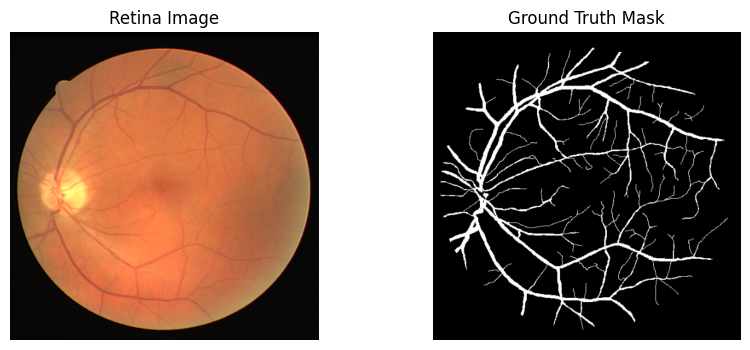

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

base_path = dataset_path + "/Data/train"

img_path = base_path + "/image/49.png"
mask_path = base_path + "/mask/49.png"

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

mask = cv2.imread(mask_path, 0)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Retina Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(mask, cmap='gray')
plt.title("Ground Truth Mask")
plt.axis('off')

plt.show()

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

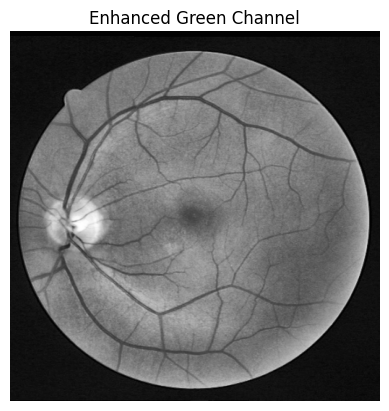

In [ ]:
green = img[:, :, 1]

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
enhanced = clahe.apply(green)

plt.imshow(enhanced, cmap='gray')
plt.title("Enhanced Green Channel")
plt.axis('off')

In [ ]:
!pip install scikit-image

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

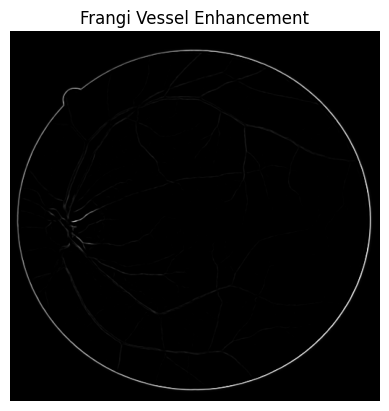

In [ ]:
from skimage.filters import frangi
from skimage import img_as_float

green = img[:, :, 1]
green = img_as_float(green)

vessels = frangi(green)

plt.imshow(vessels, cmap='gray')
plt.title("Frangi Vessel Enhancement")
plt.axis('off')

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

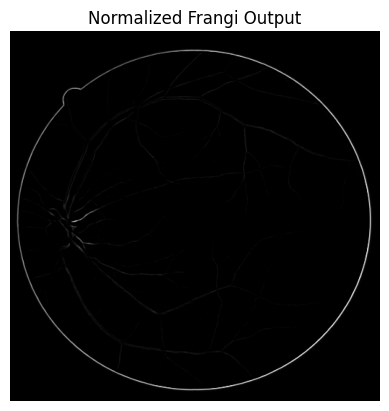

In [ ]:
import numpy as np

vessels_norm = (vessels - vessels.min()) / (vessels.max() - vessels.min())

plt.imshow(vessels_norm, cmap='gray')
plt.title("Normalized Frangi Output")
plt.axis('off')

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

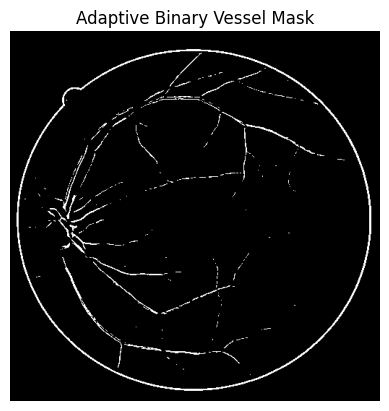

In [ ]:
th = np.mean(vessels_norm) + 0.5 * np.std(vessels_norm)

vessels_bin = (vessels_norm > th).astype(np.uint8) * 255

plt.imshow(vessels_bin, cmap='gray')
plt.title("Adaptive Binary Vessel Mask")
plt.axis('off')

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

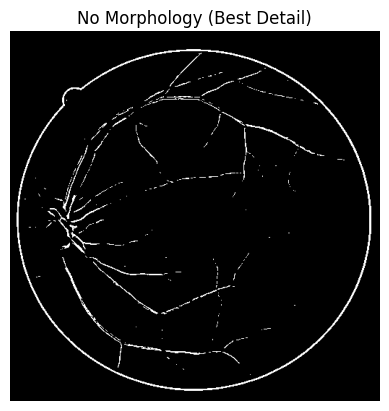

In [ ]:
plt.imshow(vessels_bin, cmap='gray')
plt.title("No Morphology (Best Detail)")
plt.axis('off')

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

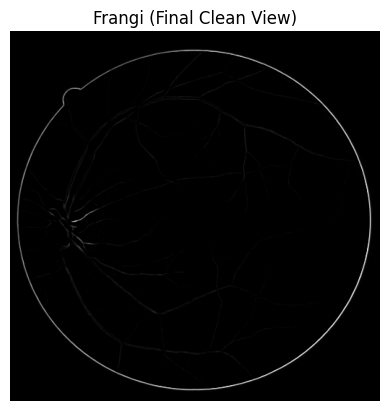

In [ ]:
vessels_norm = (vessels - vessels.min()) / (vessels.max() - vessels.min())

plt.imshow(vessels_norm, cmap='gray')
plt.title("Frangi (Final Clean View)")
plt.axis('off')

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

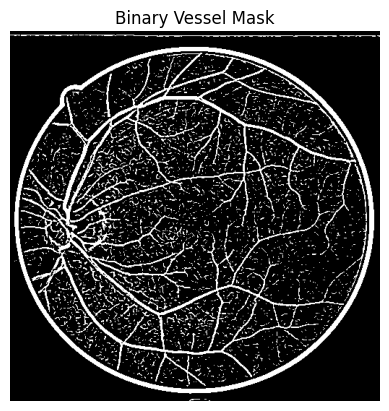

In [ ]:
th = np.percentile(vessels_norm, 85)

vessels_bin = (vessels_norm > th).astype(np.uint8)

plt.imshow(vessels_bin, cmap='gray')
plt.title("Binary Vessel Mask")
plt.axis('off')

In [ ]:
gt = (mask > 0).astype(np.uint8)
pred = (vessels_bin > 0).astype(np.uint8)

In [ ]:
intersection = np.logical_and(gt, pred).sum()
union = np.logical_or(gt, pred).sum()

iou = intersection / union
print("IoU:", iou)

IoU: 0.3329238093409863


In [ ]:
dice = (2 * intersection) / (gt.sum() + pred.sum())
print("Dice Score:", dice)

Dice Score: 0.4995391439599055


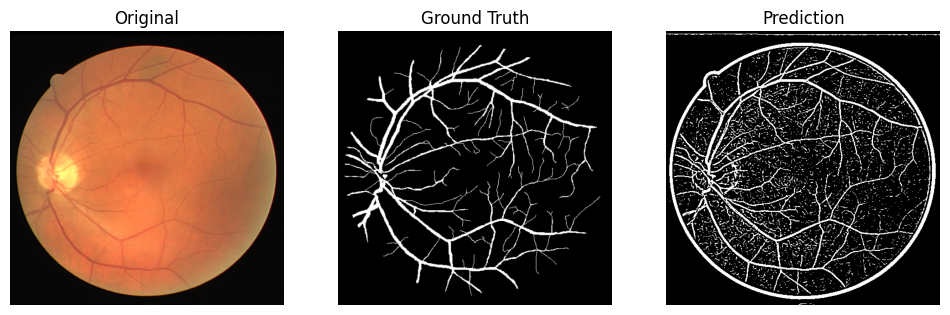

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img)
plt.title("Original")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(mask, cmap='gray')
plt.title("Ground Truth")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(vessels_bin, cmap='gray')
plt.title("Prediction")
plt.axis('off')

plt.show()

In [ ]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt

base_path = dataset_path + "/Data/train"

img_dir = base_path + "/image"
mask_dir = base_path + "/mask"

images = os.listdir(img_dir)

In [ ]:
ious = []
dices = []

for img_name in images[:20]:

    img_path = os.path.join(img_dir, img_name)
    mask_path = os.path.join(mask_dir, img_name)

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    mask = cv2.imread(mask_path, 0)

    green = img[:, :, 1]

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    enhanced = clahe.apply(green)

    vessels = frangi(enhanced / 255.0)

    vessels_norm = (vessels - vessels.min()) / (vessels.max() - vessels.min() + 1e-8)

    th = np.percentile(vessels_norm, 85)
    pred = (vessels_norm > th).astype(np.uint8)

    gt = (mask > 0).astype(np.uint8)

    intersection = np.logical_and(gt, pred).sum()
    union = np.logical_or(gt, pred).sum()

    iou = intersection / (union + 1e-8)
    dice = (2 * intersection) / (gt.sum() + pred.sum() + 1e-8)

    ious.append(iou)
    dices.append(dice)

    print(f"{img_name} -> IoU: {iou:.3f} | Dice: {dice:.3f}")

49.png -> IoU: 0.347 | Dice: 0.515
55.png -> IoU: 0.339 | Dice: 0.507
70.png -> IoU: 0.381 | Dice: 0.552
45.png -> IoU: 0.347 | Dice: 0.516
23.png -> IoU: 0.319 | Dice: 0.484
71.png -> IoU: 0.379 | Dice: 0.549
73.png -> IoU: 0.381 | Dice: 0.552
44.png -> IoU: 0.347 | Dice: 0.515
41.png -> IoU: 0.288 | Dice: 0.447
77.png -> IoU: 0.364 | Dice: 0.534
21.png -> IoU: 0.313 | Dice: 0.477
19.png -> IoU: 0.305 | Dice: 0.468
25.png -> IoU: 0.362 | Dice: 0.532
42.png -> IoU: 0.289 | Dice: 0.448
36.png -> IoU: 0.314 | Dice: 0.478
59.png -> IoU: 0.392 | Dice: 0.563
53.png -> IoU: 0.342 | Dice: 0.509
50.png -> IoU: 0.346 | Dice: 0.515
24.png -> IoU: 0.362 | Dice: 0.532
16.png -> IoU: 0.304 | Dice: 0.466


In [ ]:
print("\n===== FINAL RESULTS =====")
print("Mean IoU:", np.mean(ious))
print("Mean Dice:", np.mean(dices))


===== FINAL RESULTS =====
Mean IoU: 0.34111017882865036
Mean Dice: 0.5079058957029281


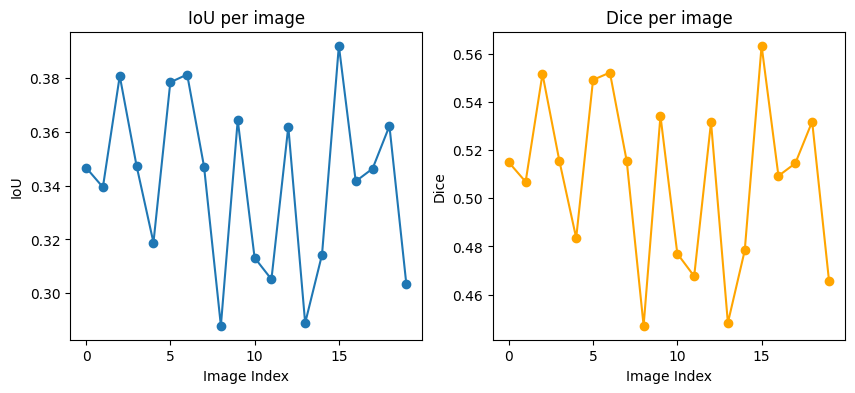

In [ ]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(ious, marker='o')
plt.title("IoU per image")
plt.xlabel("Image Index")
plt.ylabel("IoU")

plt.subplot(1,2,2)
plt.plot(dices, marker='o', color='orange')
plt.title("Dice per image")
plt.xlabel("Image Index")
plt.ylabel("Dice")

plt.show()

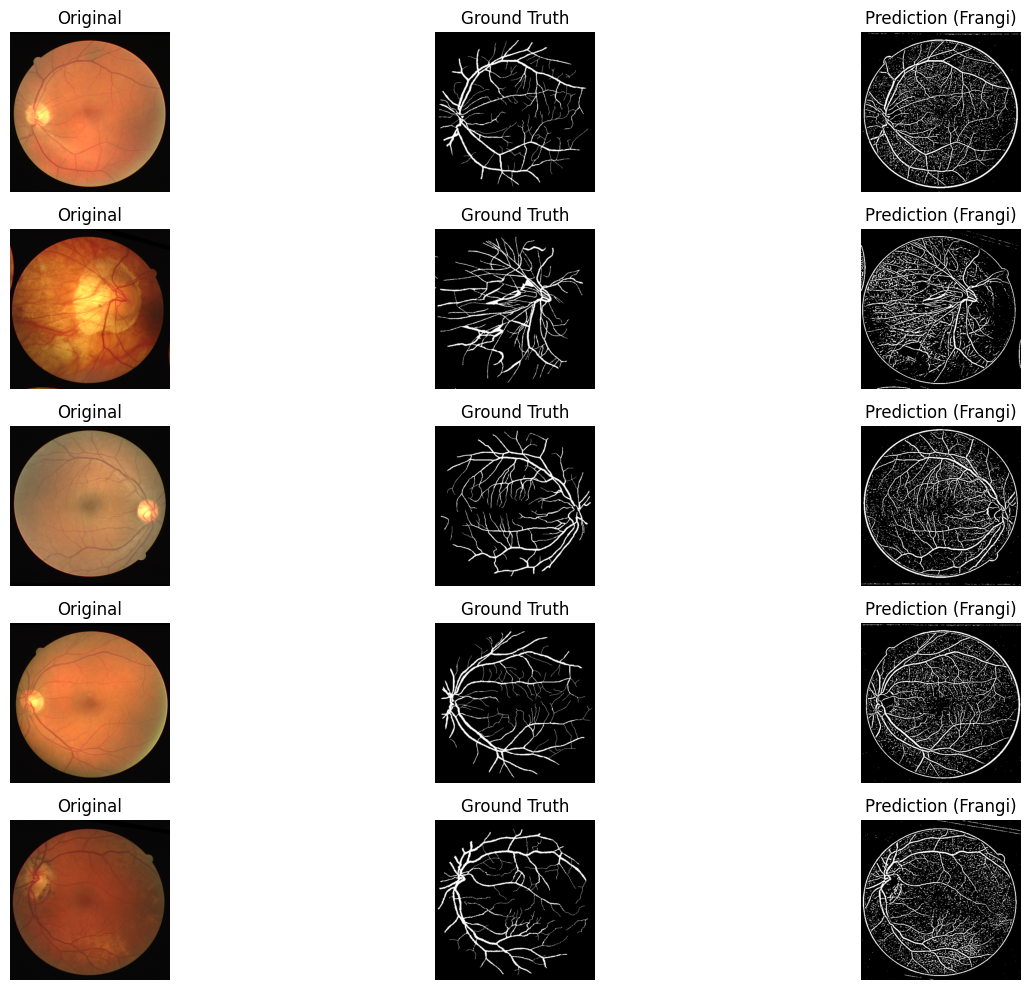

In [ ]:
import matplotlib.pyplot as plt
import cv2
import os

base_path = dataset_path + "/Data/train"
img_dir = base_path + "/image"
mask_dir = base_path + "/mask"

files = os.listdir(img_dir)[:5]  # أول 5 صور

plt.figure(figsize=(15, 10))

for i, f in enumerate(files):

    # ===== Load image =====
    img = cv2.imread(os.path.join(img_dir, f))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    mask = cv2.imread(os.path.join(mask_dir, f), 0)

    # ===== Pipeline (Frangi prediction) =====
    green = img[:, :, 1]

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    enhanced = clahe.apply(green)

    vessels = frangi(enhanced / 255.0)

    vessels_norm = (vessels - vessels.min()) / (vessels.max() - vessels.min() + 1e-8)

    th = np.percentile(vessels_norm, 85)
    pred = (vessels_norm > th).astype(np.uint8)

    # ===== Plot =====
    plt.subplot(5, 3, i*3 + 1)
    plt.imshow(img)
    plt.title("Original")
    plt.axis('off')

    plt.subplot(5, 3, i*3 + 2)
    plt.imshow(mask, cmap='gray')
    plt.title("Ground Truth")
    plt.axis('off')

    plt.subplot(5, 3, i*3 + 3)
    plt.imshow(pred, cmap='gray')
    plt.title("Prediction (Frangi)")
    plt.axis('off')

plt.tight_layout()
plt.show()